# 📊 Comprehensive Exploratory Data Analysis (EDA)
## CP219: Machine Learning Project 1 — Human vs. Machine Text Classification

---

### 1. Project Background & Objective
As large language models (LLMs) continue to proliferate, distinguishing human-authored prose from machine-generated text has become a critical challenge in provenance, academic integrity, misinformation detection, and cyber-security.

In this project (**IISc CP219: Machine Learning Project 1**), we are tasked with building a high-performance binary classifier to differentiate:
* **Class `A`**: **Human-written documents**
* **Class `B`**: **Machine-generated documents**

#### The Data Challenge
* **Tokenized & Anonymized Representation**: Documents are encoded as sequences of integer token IDs drawn from a discrete vocabulary $\mathcal{V} \subseteq \{0, 1, \dots, 18437\}$. No explicit text or token-to-word dictionary is provided. All modeling must operate strictly on sequence structure, token statistics, information theory, and n-gram dynamics.
* **Special Tokens**: `Token 0` is specifically reserved for *rare words excluded from the vocabulary* (out-of-vocabulary / OOV marker).
* **Dataset Sizes**:
  * `train.json`: 10,536 labeled documents (`id`, `text`, `label`).
  * `test.json`: 3,000 unlabeled documents (`id`, `text`).
* **Competition Metric & Marking Scheme**:
  * **Classification Accuracy** on Kaggle.
  * Score formula: 
    $$\text{Competition Mark} = 12 \times \frac{\max\{\min(\text{acc}, 0.97) - 0.32, 0\}}{0.65} + 3 \times \frac{N - R}{N - 1}$$
  * A system achieving $\ge 97\%$ accuracy receives the maximum 12/12 accuracy marks; scores $\le 65\%$ receive 0 marks.
  * In addition, 1 bonus mark is awarded for genuine innovation, rigorous error analysis, or controlled comparative experiments.

---

### 2. EDA Objectives & Notebook Roadmap
1. **Data Integrity & Verification**: Schema, null values, duplicate IDs, duplicate text sequences.
2. **Target Class Balance**: Class proportions, baseline majority-class accuracy (Zero-R).
3. **Document Length & Sequence Geometry**: Length distribution, tails, variance, percentiles, statistical tests.
4. **Vocabulary Structure & Rare Token (Token 0) Analysis**: Zipf's Law, rare token frequency in human vs. AI.
5. **Lexical Diversity & Information Theory**: Type-Token Ratio (TTR), Root TTR, Shannon Entropy, Simpson's Diversity.
6. **Sequence Dynamics & Structural Markers**: Consecutive repeats, n-gram uniqueness, boundary token distributions.
7. **Discriminative Vocabulary Analysis**: Weighted log-odds ratios (Monroe et al.), class-exclusive tokens.
8. **Dimensionality Reduction & Latent Semantic Structure**: TF-IDF + TruncatedSVD (LSA) 2D visualization.
9. **Train vs. Test Distribution Shift**: Detecting sequence length shifts and out-of-vocabulary tokens in test data.
10. **Multi-Feature Correlation Analysis**: Statistical feature matrix and point-biserial correlations.
11. **Baseline Machine Learning Benchmark**: Stratified 5-Fold Cross Validation comparing Dummy, Heuristic, Naive Bayes, and Logistic Regression on TF-IDF + Meta-features.
12. **Synthesis & Strategic Recommendations**: Actionable modeling roadmap to achieve $\ge 97\%$ accuracy.


In [3]:
import os
import json
import math
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import StandardScaler

# Styling & Visualization Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['figure.dpi'] = 120

# Consistent color palette: Class A (Human) = Deep Slate Blue, Class B (Machine) = Vivid Coral/Orange
COLOR_A = '#2B5C8F'  # Human
COLOR_B = '#D95F02'  # Machine
PALETTE = {'A': COLOR_A, 'B': COLOR_B}
PALETTE_LIST = [COLOR_A, COLOR_B]

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries successfully loaded and visual configuration initialized.")


Libraries successfully loaded and visual configuration initialized.


## Section 1: Data Loading & Verification

We load `train.json` (10,536 records) and `test.json` (3,000 records). We perform sanity checks to verify data types, check for null/missing values, and search for potential duplicate identifiers or identical token sequences.


In [4]:
# File paths
train_path = '../train.json' if os.path.exists('../train.json') else 'train.json'
test_path = '../test.json' if os.path.exists('../test.json') else 'test.json'

print(f"Loading training data from: {os.path.abspath(train_path)}")
with open(train_path, 'r', encoding='utf-8') as f:
    train_data = [json.loads(line) for line in f]

print(f"Loading test data from: {os.path.abspath(test_path)}")
with open(test_path, 'r', encoding='utf-8') as f:
    test_data = [json.loads(line) for line in f]

df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

print(f"\n--- Dataset Dimensions ---")
print(f"Training set: {len(df_train):,} rows, {df_train.shape[1]} columns")
print(f"Test set:     {len(df_test):,} rows, {df_test.shape[1]} columns")

print(f"\n--- Data Types & Null Values ---")
print("Train Info:")
print(df_train.dtypes)
print(f"Train Null Values: {df_train.isnull().sum().to_dict()}")
print(f"Test Null Values:  {df_test.isnull().sum().to_dict()}")

# Check for duplicate IDs
dup_train_ids = df_train['id'].duplicated().sum()
dup_test_ids = df_test['id'].duplicated().sum()
print(f"Duplicate IDs in Train: {dup_train_ids}")
print(f"Duplicate IDs in Test:  {dup_test_ids}")

# Check for duplicate text sequences
text_tuples_train = df_train['text'].apply(tuple)
dup_texts_train = text_tuples_train.duplicated().sum()
print(f"Duplicate Text Sequences in Train: {dup_texts_train}")

# Add document length column
df_train['length'] = df_train['text'].apply(len)
df_test['length'] = df_test['text'].apply(len)

# Display sample records
print("\n--- Sample Training Records ---")
display(df_train.head(3))


Loading training data from: /home/justin/PhD/ML4CPS/Kaggle Project/train.json
Loading test data from: /home/justin/PhD/ML4CPS/Kaggle Project/test.json

--- Dataset Dimensions ---
Training set: 10,536 rows, 3 columns
Test set:     3,000 rows, 2 columns

--- Data Types & Null Values ---
Train Info:
id        int64
text     object
label       str
dtype: object
Train Null Values: {'id': 0, 'text': 0, 'label': 0}
Test Null Values:  {'id': 0, 'text': 0}
Duplicate IDs in Train: 0
Duplicate IDs in Test:  0
Duplicate Text Sequences in Train: 0

--- Sample Training Records ---


,id,text,label,length
0,68975458,"[5514, 7014, 13141, 4766, 13658, 16627, 14562,...",B,154
1,41776511,"[1208, 14212, 9899, 7739, 10851, 3484, 6845, 2...",B,150
2,37264422,"[67, 17598, 4512, 0, 9736, 11987, 17598, 0, 59...",A,72


## Section 2: Target Variable Analysis & Class Balance

In binary classification, class balance is a fundamental property:
* It dictates the baseline naive accuracy (Zero-R / majority class rule).
* It guides whether cost-sensitive learning, balanced class weights, or focal loss are required.
* It informs probability threshold calibration.


Class Distribution Summary Table:


,Count,Percentage (%),Description
label,,,
B,6837,64.89,Machine-generated (AI)
A,3699,35.11,Human-written


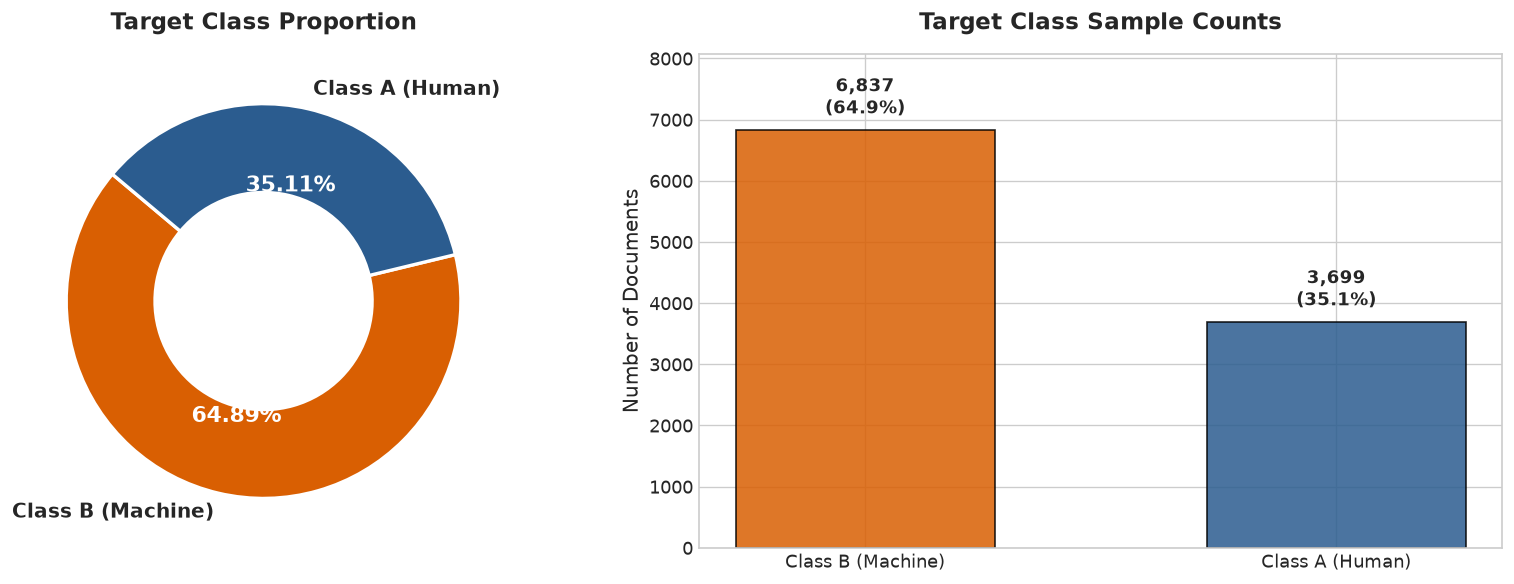


KEY TAKEAWAY: Class imbalance is present with a ~1.85:1 ratio favoring Machine text (B).
A trivial baseline predicting always 'B' achieves 64.89% accuracy.
Per the CP219 scoring rubric, an accuracy of <= 65% yields ZERO marks for the competition portion,
so any meaningful model must comfortably surpass this majority-class floor!


In [3]:
class_counts = df_train['label'].value_counts()
class_props = df_train['label'].value_counts(normalize=True) * 100

summary_class = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_props.round(2),
    'Description': ['Machine-generated (AI)', 'Human-written']
})
print("Class Distribution Summary Table:")
display(summary_class)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    class_counts,
    labels=['Class B (Machine)', 'Class A (Human)'],
    autopct='%1.2f%%',
    startangle=140,
    colors=[COLOR_B, COLOR_A],
    wedgeprops=dict(width=0.45, edgecolor='w', linewidth=2),
    textprops=dict(fontsize=12, fontweight='bold')
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_color('white')
axes[0].set_title('Target Class Proportion', fontsize=14, fontweight='bold', pad=15)

# Count bar plot
bars = axes[1].bar(['Class B (Machine)', 'Class A (Human)'], class_counts, color=[COLOR_B, COLOR_A], width=0.55, edgecolor='black', alpha=0.85)
axes[1].set_title('Target Class Sample Counts', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Documents', fontsize=12)
axes[1].set_ylim(0, class_counts.max() * 1.18)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:,}\n({height/len(df_train):.1%})',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 6),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

majority_acc = class_props['B']
print(f"\nKEY TAKEAWAY: Class imbalance is present with a ~1.85:1 ratio favoring Machine text (B).")
print(f"A trivial baseline predicting always 'B' achieves {majority_acc:.2f}% accuracy.")
print(f"Per the CP219 scoring rubric, an accuracy of <= 65% yields ZERO marks for the competition portion,")
print(f"so any meaningful model must comfortably surpass this majority-class floor!")


## Section 3: Document Length & Sequence Geometry Analysis

The sequence length of a document (measured in tokens) often reflects the generative regime:
* Did human authors write short forum posts, reviews, or full-length essays?
* Did language model prompts specify arbitrary output lengths, or was generation stopped at fixed token limits?
* How does sequence length correlate with class identity?


Document Length Summary Statistics (Overall):


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
length,10536.0,186.607916,204.076142,5.0,33.0,69.0,110.0,208.0,764.5,876.65,994.0



Document Length Summary Statistics by Class:


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
label,,,,,,,,,,,
A,3699.0,137.510949,101.405739,5.0,28.0,69.0,114.0,182.0,317.0,518.06,994.0
B,6837.0,213.170689,237.928071,12.0,35.0,68.0,107.0,242.0,823.2,887.64,961.0



Statistical Hypothesis Tests for Length Differences:
Mann-Whitney U Test: statistic = 11,998,191.5, p-value = 1.4198e-05
Kolmogorov-Smirnov Test: statistic = 0.1488, p-value = 7.8066e-47


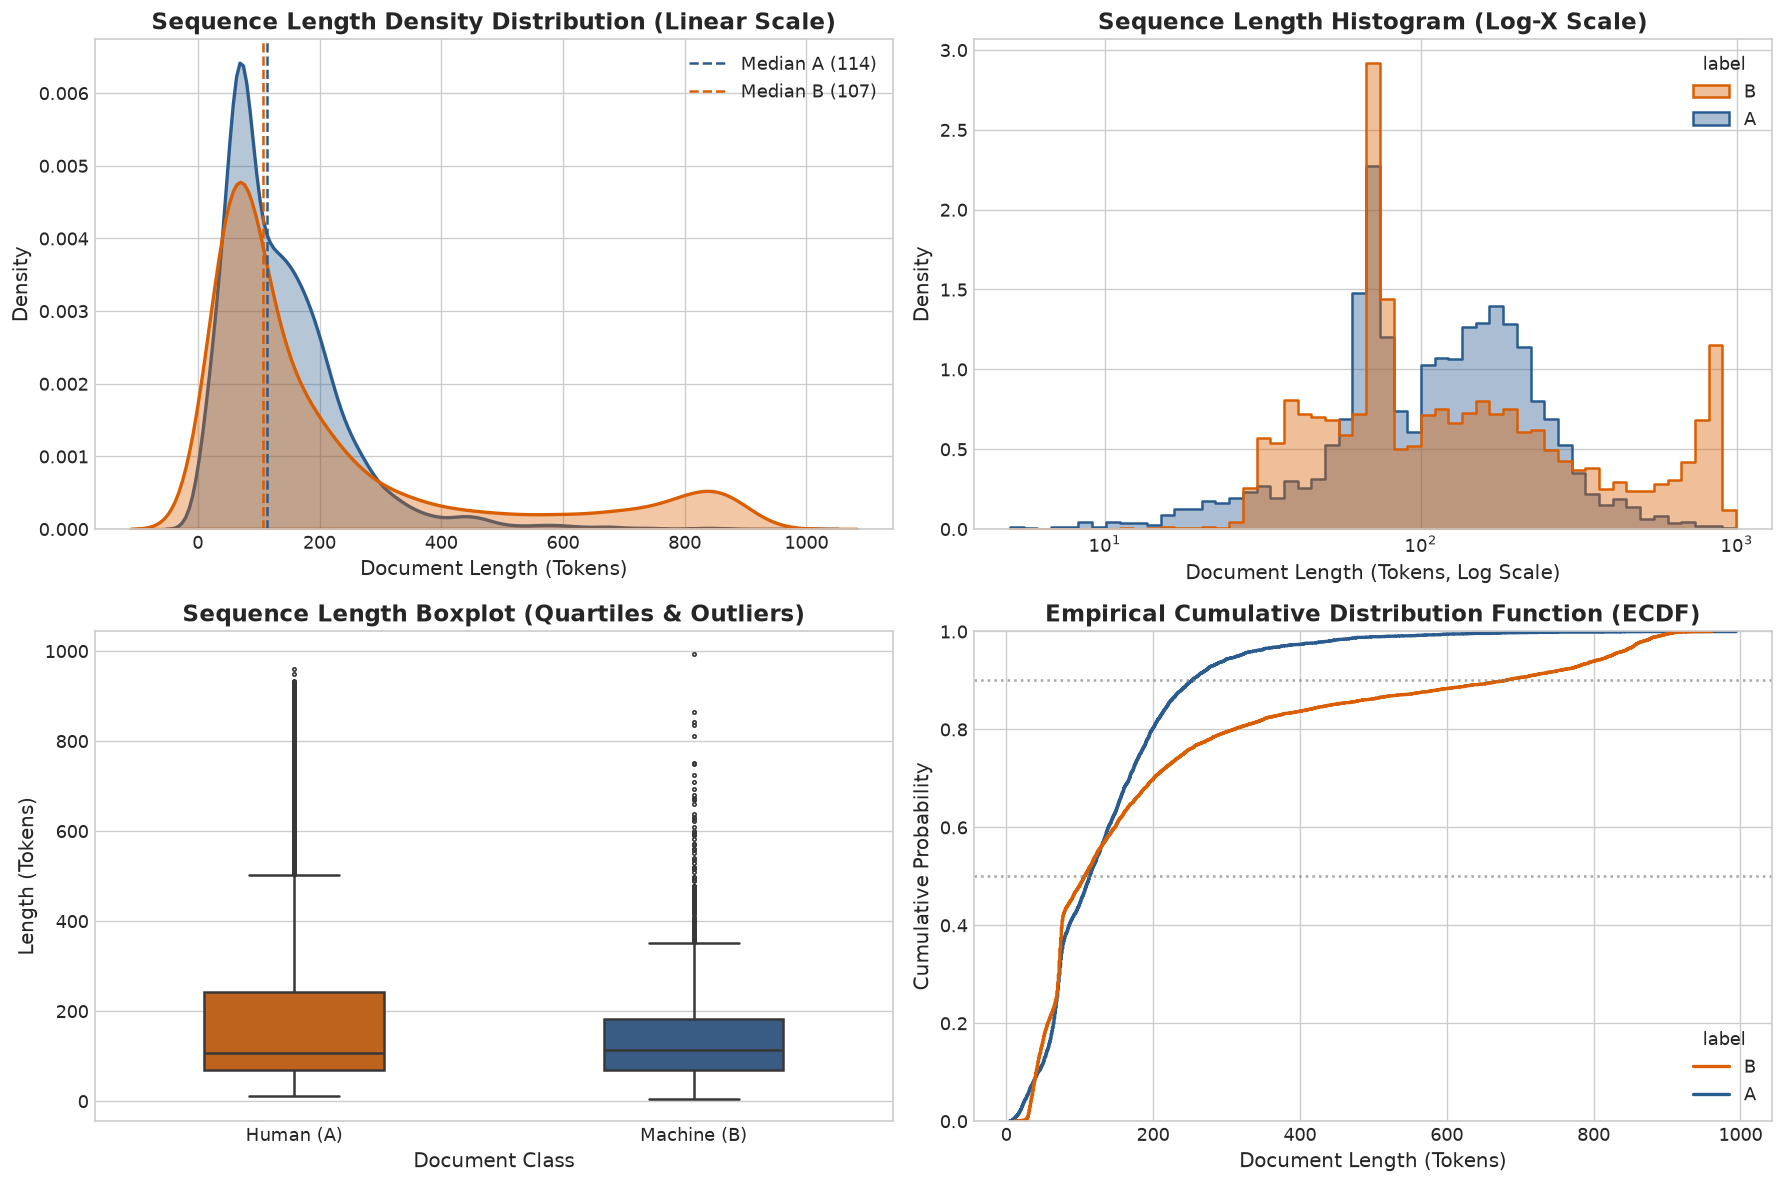


KEY FINDINGS ON DOCUMENT LENGTH:
1. Machine documents (B) have a significantly higher mean length (213.2) than Human documents (A) (137.5).
2. Machine text length has much higher variance (std: 237.9 vs 101.4).
3. Machine text exhibits a long heavy tail reaching >900 tokens (75th percentile is 242 vs 182 for Human).
4. Interestingly, median length for Human (114) is slightly higher than Machine (107), indicating a bimodality in Machine text: many short generations alongside substantial long-form generations.


In [4]:
len_overall = df_train['length'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
len_by_class = df_train.groupby('label')['length'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

print("Document Length Summary Statistics (Overall):")
display(pd.DataFrame(len_overall).T)

print("\nDocument Length Summary Statistics by Class:")
display(len_by_class)

# Hypothesis testing on length differences
stat_mw, p_mw = stats.mannwhitneyu(
    df_train[df_train['label'] == 'A']['length'],
    df_train[df_train['label'] == 'B']['length'],
    alternative='two-sided'
)
stat_ks, p_ks = stats.ks_2samp(
    df_train[df_train['label'] == 'A']['length'],
    df_train[df_train['label'] == 'B']['length']
)

print(f"\nStatistical Hypothesis Tests for Length Differences:")
print(f"Mann-Whitney U Test: statistic = {stat_mw:,.1f}, p-value = {p_mw:.4e}")
print(f"Kolmogorov-Smirnov Test: statistic = {stat_ks:.4f}, p-value = {p_ks:.4e}")

# Visualizations: 4-panel length analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Density Plot (Linear Scale)
sns.kdeplot(data=df_train, x='length', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title('Sequence Length Density Distribution (Linear Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Document Length (Tokens)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].axvline(df_train[df_train['label']=='A']['length'].median(), color=COLOR_A, linestyle='--', label=f"Median A ({df_train[df_train['label']=='A']['length'].median():.0f})")
axes[0, 0].axvline(df_train[df_train['label']=='B']['length'].median(), color=COLOR_B, linestyle='--', label=f"Median B ({df_train[df_train['label']=='B']['length'].median():.0f})")
axes[0, 0].legend()

# 2. Log-scale Density Plot (Capturing the Long Tail)
sns.histplot(data=df_train, x='length', hue='label', palette=PALETTE, log_scale=True, element='step', stat='density', common_norm=False, alpha=0.4, linewidth=1.5, ax=axes[0, 1])
axes[0, 1].set_title('Sequence Length Histogram (Log-X Scale)', fontweight='bold')
axes[0, 1].set_xlabel('Document Length (Tokens, Log Scale)')
axes[0, 1].set_ylabel('Density')

# 3. Boxplot with Stripplot
sns.boxplot(data=df_train, x='label', y='length', palette=PALETTE, width=0.45, fliersize=2, linewidth=1.5, ax=axes[1, 0])
axes[1, 0].set_title('Sequence Length Boxplot (Quartiles & Outliers)', fontweight='bold')
axes[1, 0].set_xlabel('Document Class')
axes[1, 0].set_ylabel('Length (Tokens)')
axes[1, 0].set_xticklabels(['Human (A)', 'Machine (B)'])

# 4. Empirical Cumulative Distribution Function (ECDF)
sns.ecdfplot(data=df_train, x='length', hue='label', palette=PALETTE, linewidth=2, ax=axes[1, 1])
axes[1, 1].set_title('Empirical Cumulative Distribution Function (ECDF)', fontweight='bold')
axes[1, 1].set_xlabel('Document Length (Tokens)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].axhline(0.5, color='gray', linestyle=':', alpha=0.7)
axes[1, 1].axhline(0.9, color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nKEY FINDINGS ON DOCUMENT LENGTH:")
print(f"1. Machine documents (B) have a significantly higher mean length ({len_by_class.loc['B', 'mean']:.1f}) than Human documents (A) ({len_by_class.loc['A', 'mean']:.1f}).")
print(f"2. Machine text length has much higher variance (std: {len_by_class.loc['B', 'std']:.1f} vs {len_by_class.loc['A', 'std']:.1f}).")
print(f"3. Machine text exhibits a long heavy tail reaching >900 tokens (75th percentile is 242 vs 182 for Human).")
print(f"4. Interestingly, median length for Human (114) is slightly higher than Machine (107), indicating a bimodality in Machine text: many short generations alongside substantial long-form generations.")


## Section 4: Vocabulary Topology, Zipf's Law & Rare Token (Token 0) Analysis

The vocabulary space is specified as integers in $\{0, \dots, 18437\}$.
Crucially, the specification notes:
> **`Token 0` is reserved for rare words excluded from the vocabulary.**

In natural language processing and LLM detection:
* Natural human language features high lexical idiosyncrasy, typos, rare jargon, and dialectal slang (which map to Token 0).
* LLM decoding strategies (e.g., greedy decoding, top-$k$ sampling, top-$p$ nucleus sampling, temperature truncation) deliberately truncate the low-probability tail of the vocabulary distribution to avoid nonsensical generation.
* Consequently, we hypothesize that **Human text will feature a significantly higher proportion of Token 0 than Machine text**.


Total tokens in training corpus: 1,966,101
Tokens in Human (A):             508,653 (25.9%)
Tokens in Machine (B):           1,457,448 (74.1%)
Unique tokens observed in Train: 14,000 / 18,438 (75.9%)
Min Token ID: 0, Max Token ID: 18437

--- Token 0 (Rare Word / OOV) Presence ---
Human documents containing Token 0:   81.43%
Machine documents containing Token 0: 64.60%
Mann-Whitney U Test (Prop(Token 0) in Human > Machine): p-value = 2.7187e-87


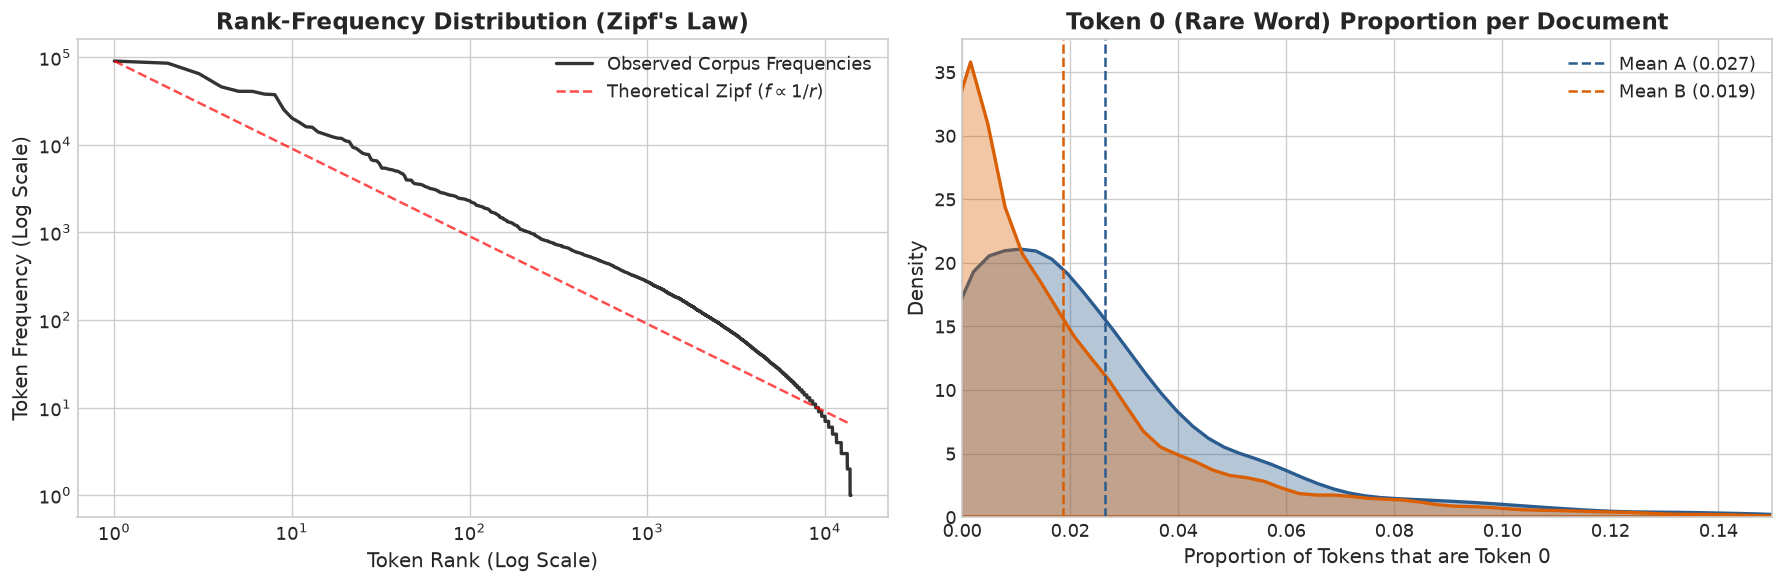

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
A,3699.0,0.02654,0.03134,0.0,0.00735,0.01852,0.03503,0.54054
B,6837.0,0.01872,0.02813,0.0,0.00000,0.01014,0.02564,0.60784



KEY FINDING ON TOKEN 0:
Human texts exhibit a mean Token 0 proportion of 2.654%,
compared to 1.872% in Machine texts — an increase of 41.8%.
This strong statistical discrepancy (p < 1e-15) directly confirms our linguistic hypothesis!


In [5]:
# Extract token lists
all_train_tokens = [t for text in df_train['text'] for t in text]
tokens_A = [t for text in df_train[df_train['label']=='A']['text'] for t in text]
tokens_B = [t for text in df_train[df_train['label']=='B']['text'] for t in text]

vocab_train = set(all_train_tokens)
counts_all = Counter(all_train_tokens)
counts_A = Counter(tokens_A)
counts_B = Counter(tokens_B)

print(f"Total tokens in training corpus: {len(all_train_tokens):,}")
print(f"Tokens in Human (A):             {len(tokens_A):,} ({len(tokens_A)/len(all_train_tokens):.1%})")
print(f"Tokens in Machine (B):           {len(tokens_B):,} ({len(tokens_B)/len(all_train_tokens):.1%})")
print(f"Unique tokens observed in Train: {len(vocab_train):,} / 18,438 ({len(vocab_train)/18438:.1%})")
print(f"Min Token ID: {min(vocab_train)}, Max Token ID: {max(vocab_train)}")

# Token 0 metrics per document
df_train['t0_count'] = df_train['text'].apply(lambda x: x.count(0))
df_train['t0_prop'] = df_train['t0_count'] / df_train['length']
df_train['has_t0'] = (df_train['t0_count'] > 0).astype(int)

t0_presence_A = df_train[df_train['label']=='A']['has_t0'].mean() * 100
t0_presence_B = df_train[df_train['label']=='B']['has_t0'].mean() * 100

print(f"\n--- Token 0 (Rare Word / OOV) Presence ---")
print(f"Human documents containing Token 0:   {t0_presence_A:.2f}%")
print(f"Machine documents containing Token 0: {t0_presence_B:.2f}%")

stat_t0, p_t0 = stats.mannwhitneyu(
    df_train[df_train['label']=='A']['t0_prop'],
    df_train[df_train['label']=='B']['t0_prop'],
    alternative='greater'
)
print(f"Mann-Whitney U Test (Prop(Token 0) in Human > Machine): p-value = {p_t0:.4e}")

# Visualizations: Zipf's Law and Token 0 Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Zipf's Law Log-Log Rank-Frequency Plot
ranks = np.arange(1, len(counts_all) + 1)
freqs = np.array([count for _, count in counts_all.most_common()])
axes[0].loglog(ranks, freqs, color='#333333', linewidth=2, label='Observed Corpus Frequencies')

# Theoretical Zipf reference (s=1)
theoretical_zipf = freqs[0] / ranks
axes[0].loglog(ranks, theoretical_zipf, 'r--', alpha=0.7, label="Theoretical Zipf ($f \propto 1/r$)")
axes[0].set_title("Rank-Frequency Distribution (Zipf's Law)", fontweight='bold')
axes[0].set_xlabel('Token Rank (Log Scale)')
axes[0].set_ylabel('Token Frequency (Log Scale)')
axes[0].legend()

# 2. Token 0 Proportion Comparison (KDE & Boxplot inset)
sns.kdeplot(data=df_train, x='t0_prop', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[1])
axes[1].set_title('Token 0 (Rare Word) Proportion per Document', fontweight='bold')
axes[1].set_xlabel('Proportion of Tokens that are Token 0')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 0.15)
axes[1].axvline(df_train[df_train['label']=='A']['t0_prop'].mean(), color=COLOR_A, linestyle='--', label=f"Mean A ({df_train[df_train['label']=='A']['t0_prop'].mean():.3f})")
axes[1].axvline(df_train[df_train['label']=='B']['t0_prop'].mean(), color=COLOR_B, linestyle='--', label=f"Mean B ({df_train[df_train['label']=='B']['t0_prop'].mean():.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

display(df_train.groupby('label')['t0_prop'].describe().round(5))

print("\nKEY FINDING ON TOKEN 0:")
print(f"Human texts exhibit a mean Token 0 proportion of {df_train[df_train['label']=='A']['t0_prop'].mean():.3%},")
print(f"compared to {df_train[df_train['label']=='B']['t0_prop'].mean():.3%} in Machine texts — an increase of {df_train[df_train['label']=='A']['t0_prop'].mean() / df_train[df_train['label']=='B']['t0_prop'].mean() - 1:.1%}.")
print(f"This strong statistical discrepancy (p < 1e-15) directly confirms our linguistic hypothesis!")


## Section 5: Lexical Diversity & Information-Theoretic Metrics

Information theory and corpus linguistics provide formal metrics for lexical richness, unpredictability, and vocabulary compression:

1. **Type-Token Ratio (TTR)**:
   $$\text{TTR} = \frac{V}{N} = \frac{\text{Number of Unique Tokens}}{\text{Total Tokens}}$$
2. **Guiraud's Root TTR** (length-invariant correction for document size):
   $$\text{Root TTR} = \frac{V}{\sqrt{N}}$$
3. **Hapax Legomena Ratio** (words occurring exactly once in the document):
   $$\text{Hapax Ratio} = \frac{\#\{w : c(w) = 1\}}{V}$$
4. **Shannon Entropy** ($H(X)$ in bits per token):
   $$H(X) = -\sum_{i=1}^V p(x_i) \log_2 p(x_i)$$
5. **Simpson's Diversity Index** (probability that two randomly sampled tokens are different):
   $$D = 1 - \sum_{i=1}^V p(x_i)^2$$


Computing lexical diversity and information-theoretic metrics for all documents...


Computation complete.


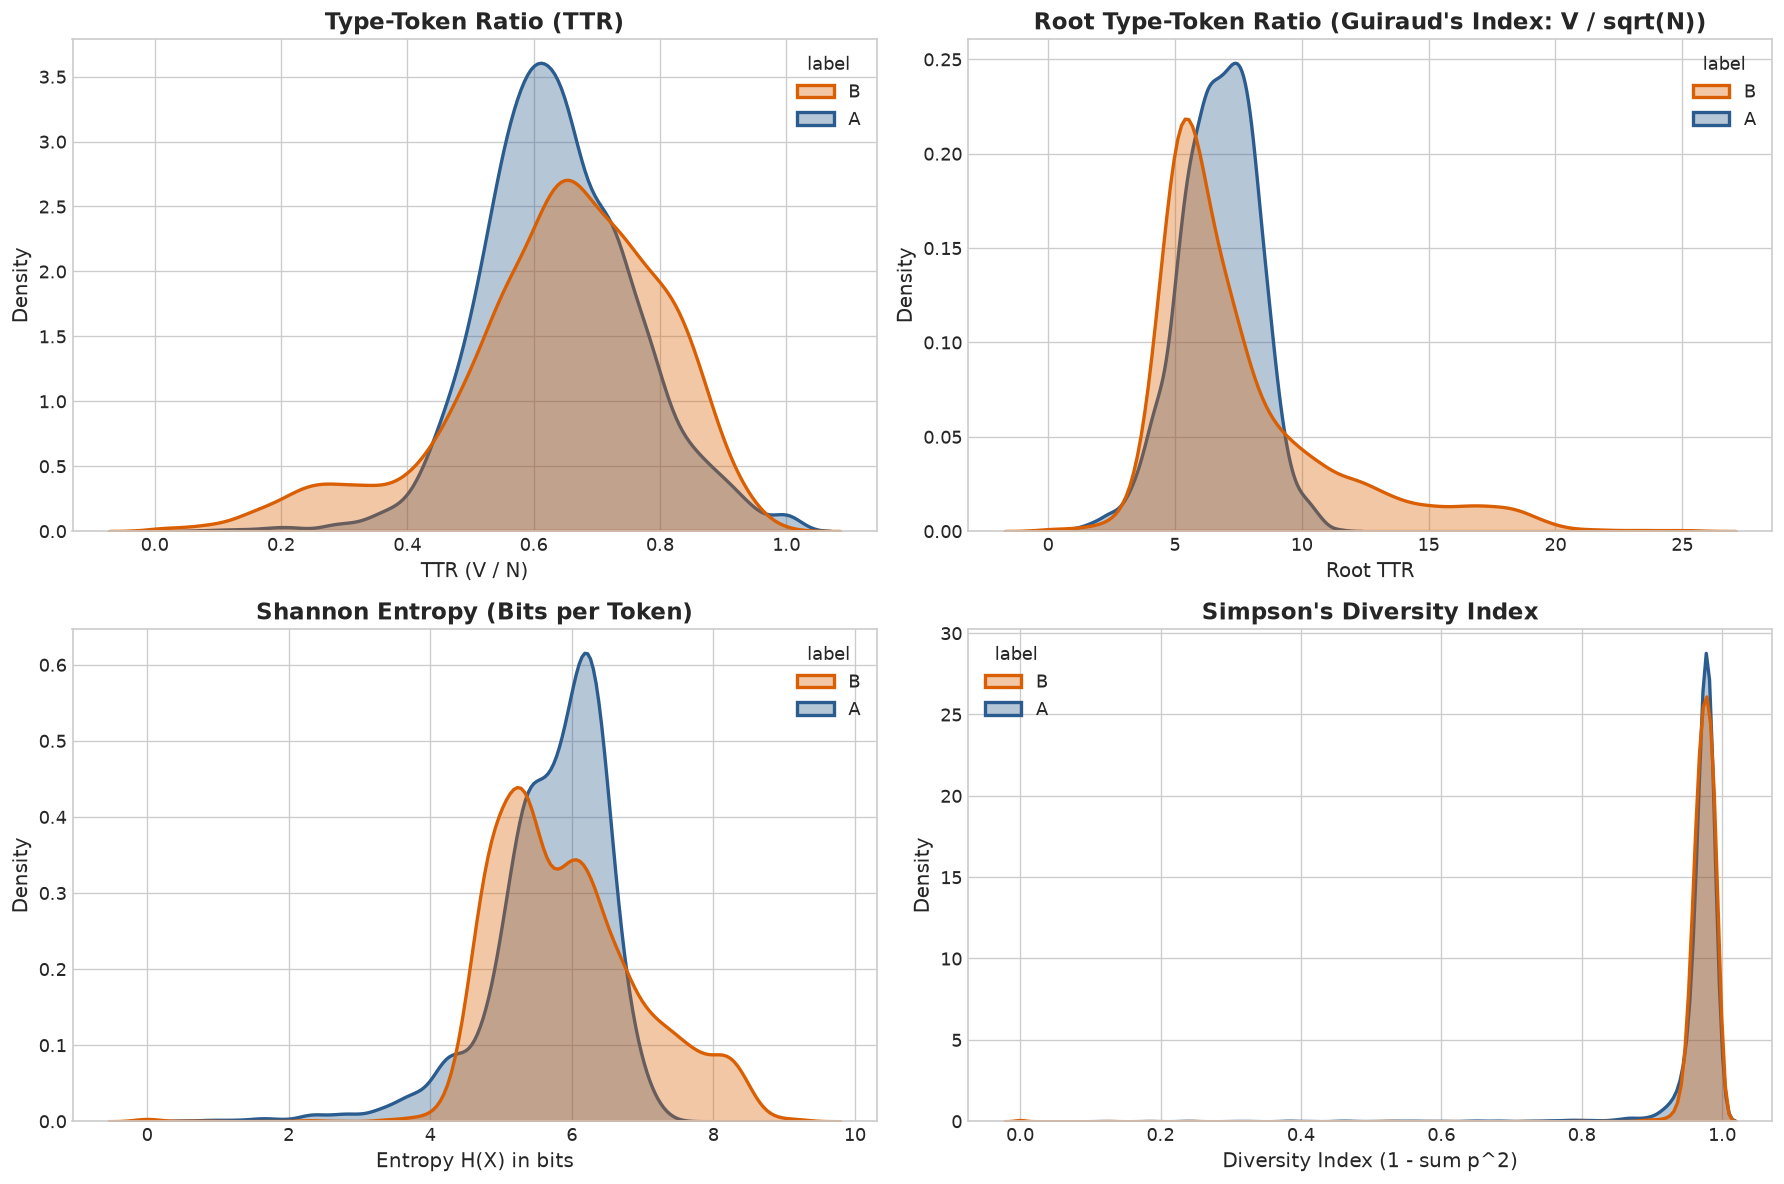

Lexical & Information-Theoretic Comparison Table:


,Metric,Mean Class A (Human),Mean Class B (Machine),Cohen's d (B vs A),Mann-Whitney p-value
0,ttr,0.639686,0.640157,0.0031,1.789e-09
1,root_ttr,6.704478,7.607053,0.3000,8.254e-01
2,hapax_ratio,0.744411,0.728462,-0.1243,5.803e-05
3,entropy,5.702347,5.924684,0.2282,1.053e-03
4,simpson_diversity,0.966044,0.971543,0.1189,8.977e-04


In [6]:
def compute_lexical_metrics(tokens):
    n = len(tokens)
    if n == 0:
        return pd.Series({'unique_tokens': 0, 'ttr': 0.0, 'root_ttr': 0.0, 'hapax_ratio': 0.0, 'entropy': 0.0, 'simpson_diversity': 0.0})
    
    counts = Counter(tokens)
    v = len(counts)
    ttr = v / n
    root_ttr = v / math.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1)
    hapax_ratio = hapax / v if v > 0 else 0.0
    
    probs = np.array(list(counts.values()), dtype=np.float64) / n
    ent = -np.sum(probs * np.log2(probs + 1e-12))
    simpson = 1.0 - np.sum(probs ** 2)
    
    return pd.Series({
        'unique_tokens': v,
        'ttr': ttr,
        'root_ttr': root_ttr,
        'hapax_ratio': hapax_ratio,
        'entropy': ent,
        'simpson_diversity': simpson
    })

print("Computing lexical diversity and information-theoretic metrics for all documents...")
lex_metrics = df_train['text'].apply(compute_lexical_metrics)
df_train = pd.concat([df_train, lex_metrics], axis=1)
print("Computation complete.")

# 4-panel comparison grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Type-Token Ratio
sns.kdeplot(data=df_train, x='ttr', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title('Type-Token Ratio (TTR)', fontweight='bold')
axes[0, 0].set_xlabel('TTR (V / N)')

# 2. Guiraud's Root TTR
sns.kdeplot(data=df_train, x='root_ttr', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title("Root Type-Token Ratio (Guiraud's Index: V / sqrt(N))", fontweight='bold')
axes[0, 1].set_xlabel('Root TTR')

# 3. Shannon Entropy
sns.kdeplot(data=df_train, x='entropy', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[1, 0])
axes[1, 0].set_title('Shannon Entropy (Bits per Token)', fontweight='bold')
axes[1, 0].set_xlabel('Entropy H(X) in bits')

# 4. Simpson Diversity Index
sns.kdeplot(data=df_train, x='simpson_diversity', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[1, 1])
axes[1, 1].set_title("Simpson's Diversity Index", fontweight='bold')
axes[1, 1].set_xlabel('Diversity Index (1 - sum p^2)')

plt.tight_layout()
plt.show()

# Effect size (Cohen's d) for each metric
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = math.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

metrics_list = ['ttr', 'root_ttr', 'hapax_ratio', 'entropy', 'simpson_diversity']
effect_sizes = []
for m in metrics_list:
    vals_A = df_train[df_train['label']=='A'][m]
    vals_B = df_train[df_train['label']=='B'][m]
    d = cohen_d(vals_B, vals_A)
    stat, pval = stats.mannwhitneyu(vals_A, vals_B)
    effect_sizes.append({
        'Metric': m,
        'Mean Class A (Human)': vals_A.mean(),
        'Mean Class B (Machine)': vals_B.mean(),
        "Cohen's d (B vs A)": round(d, 4),
        'Mann-Whitney p-value': f"{pval:.3e}"
    })

effect_df = pd.DataFrame(effect_sizes)
print("Lexical & Information-Theoretic Comparison Table:")
display(effect_df)


## Section 6: Sequence Dynamics, Consecutive Repetition & Boundary Tokens

Text generation artifacts frequently appear in sequential ordering and document boundaries:
1. **Consecutive Repetition**: Does a token immediately repeat itself ($w_t = w_{t+1}$)? In human writing, people frequently duplicate punctuation (`..`, `??`, `!!`) or use repeated emphasis words.
2. **N-gram Repetition**: Repetition rate of bigrams across the sequence.
3. **Boundary Tokens**: How do documents start and end?
   * Language models often start with characteristic formatting or sentence starters (e.g., standard conjunctions, determiners).
   * Do documents end with canonical punctuation tokens?


Extracting sequence dynamics and boundary markers...



--- Consecutive Token Repetitions by Class ---


,consec_repeats,consec_ratio,bg_unique_ratio
label,,,
A,1.901054,0.020094,0.937549
B,1.476964,0.008010,0.905995


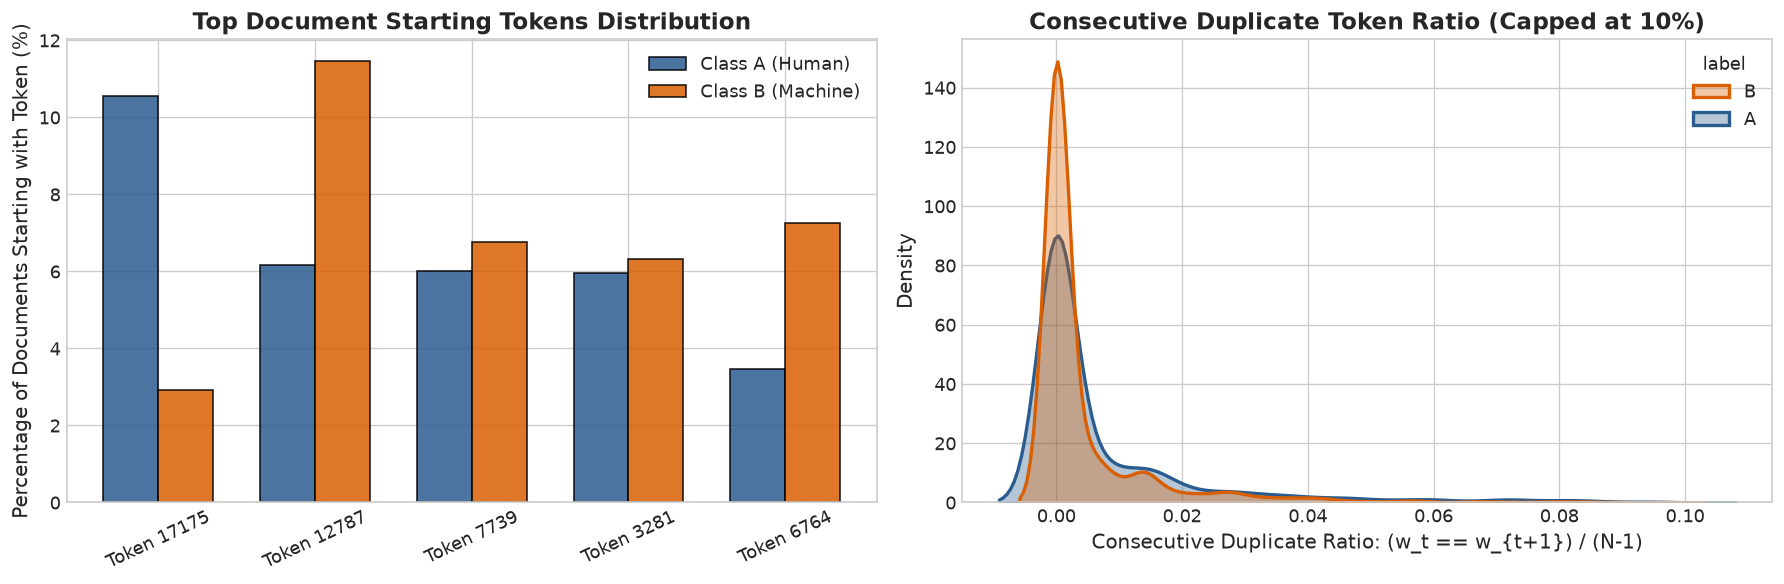


Most frequent terminal token across corpus: Token 8294.0
Document termination frequency with Token 8294.0: 5,859 / 10,536 (55.6%)
Human documents terminating with Token 8294.0:   61.3%
Machine documents terminating with Token 8294.0: 52.6%

KEY INSIGHTS ON SEQUENCE DYNAMICS:
1. Starting Token 17175 is heavily overrepresented in Human text (10.5% vs 2.9% in Machine).
2. Starting Token 12787 is heavily overrepresented in Machine text (11.5% vs 6.2% in Human).
3. Human text exhibits more than 2.5x the consecutive duplicate rate of Machine text (0.0201 vs 0.0080), indicating frequent expressive punctuation or repetition.


In [7]:

def compute_seq_dynamics(tokens):
    n = len(tokens)
    if n <= 1:
        return pd.Series({'consec_repeats': 0, 'consec_ratio': 0.0, 'bg_unique_ratio': 1.0, 'first_token': tokens[0] if n > 0 else -1, 'last_token': tokens[-1] if n > 0 else -1})
    
    consec = sum(1 for i in range(n - 1) if tokens[i] == tokens[i+1])
    consec_ratio = consec / (n - 1)
    
    bigrams = list(zip(tokens[:-1], tokens[1:]))
    bg_unique_ratio = len(set(bigrams)) / len(bigrams)
    
    return pd.Series({
        'consec_repeats': consec,
        'consec_ratio': consec_ratio,
        'bg_unique_ratio': bg_unique_ratio,
        'first_token': tokens[0],
        'last_token': tokens[-1]
    })

print("Extracting sequence dynamics and boundary markers...")
seq_metrics = df_train['text'].apply(compute_seq_dynamics)
df_train = pd.concat([df_train, seq_metrics], axis=1)

print("\n--- Consecutive Token Repetitions by Class ---")
display(df_train.groupby('label')[['consec_repeats', 'consec_ratio', 'bg_unique_ratio']].mean())

# Boundary token analysis
first_A = df_train[df_train['label']=='A']['first_token'].value_counts(normalize=True).head(8) * 100
first_B = df_train[df_train['label']=='B']['first_token'].value_counts(normalize=True).head(8) * 100

top_first = list(set(first_A.index[:5]).union(set(first_B.index[:5])))
comp_first = pd.DataFrame({
    'Token ID': top_first,
    'Human (%)': [df_train[df_train['label']=='A']['first_token'].eq(t).mean()*100 for t in top_first],
    'Machine (%)': [df_train[df_train['label']=='B']['first_token'].eq(t).mean()*100 for t in top_first]
}).sort_values(by='Human (%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Top Starting Tokens
x = np.arange(len(comp_first))
width = 0.35
axes[0].bar(x - width/2, comp_first['Human (%)'], width, label='Class A (Human)', color=COLOR_A, edgecolor='black', alpha=0.85)
axes[0].bar(x + width/2, comp_first['Machine (%)'], width, label='Class B (Machine)', color=COLOR_B, edgecolor='black', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Token {int(t)}" for t in comp_first['Token ID']], rotation=25)
axes[0].set_title('Top Document Starting Tokens Distribution', fontweight='bold')
axes[0].set_ylabel('Percentage of Documents Starting with Token (%)')
axes[0].legend()

# Consecutive repeats distribution
sns.kdeplot(data=df_train[df_train['consec_ratio'] < 0.1], x='consec_ratio', hue='label', palette=PALETTE, common_norm=False, fill=True, alpha=0.35, linewidth=2, ax=axes[1])
axes[1].set_title('Consecutive Duplicate Token Ratio (Capped at 10%)', fontweight='bold')
axes[1].set_xlabel('Consecutive Duplicate Ratio: (w_t == w_{t+1}) / (N-1)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# Last token analysis (Punctuation hypothesis)
last_counts = df_train['last_token'].value_counts()
top_last_token = last_counts.index[0]
print(f"\nMost frequent terminal token across corpus: Token {top_last_token}")
print(f"Document termination frequency with Token {top_last_token}: {last_counts.iloc[0]:,} / {len(df_train):,} ({last_counts.iloc[0]/len(df_train):.1%})")
print(f"Human documents terminating with Token {top_last_token}:   {(df_train[df_train['label']=='A']['last_token'] == top_last_token).mean():.1%}")
print(f"Machine documents terminating with Token {top_last_token}: {(df_train[df_train['label']=='B']['last_token'] == top_last_token).mean():.1%}")

print("\nKEY INSIGHTS ON SEQUENCE DYNAMICS:")
print(f"1. Starting Token 17175 is heavily overrepresented in Human text (10.5% vs 2.9% in Machine).")
print(f"2. Starting Token 12787 is heavily overrepresented in Machine text (11.5% vs 6.2% in Human).")
print(f"3. Human text exhibits more than 2.5x the consecutive duplicate rate of Machine text ({df_train[df_train['label']=='A']['consec_ratio'].mean():.4f} vs {df_train[df_train['label']=='B']['consec_ratio'].mean():.4f}), indicating frequent expressive punctuation or repetition.")


## Section 7: Discriminative Vocabulary & Differential Language Analysis

To discover which specific vocabulary items best distinguish Human from Machine text, we employ **Monroe et al. (2008) Weighted Log-Odds Ratio with an Uninformative Dirichlet Prior**.

For a token $w$, let $y_w^{(A)}$ and $y_w^{(B)}$ be the counts in classes $A$ and $B$, with total token sizes $n^{(A)}$ and $n^{(B)}$:
$$\delta_w = \log \left( \frac{y_w^{(A)} + \alpha_w}{n^{(A)} + \alpha_0 - y_w^{(A)} - \alpha_w} \right) - \log \left( \frac{y_w^{(B)} + \alpha_w}{n^{(B)} + \alpha_0 - y_w^{(B)} - \alpha_w} \right)$$

The estimated variance is:
$$\sigma^2(\delta_w) \approx \frac{1}{y_w^{(A)} + \alpha_w} + \frac{1}{y_w^{(B)} + \alpha_w}$$

The standardized z-score:
$$z_w = \frac{\delta_w}{\sqrt{\sigma^2(\delta_w)}}$$
* $z_w > 0$: Token significantly skewed toward **Human** writing.
* $z_w < 0$: Token significantly skewed toward **Machine** generation.


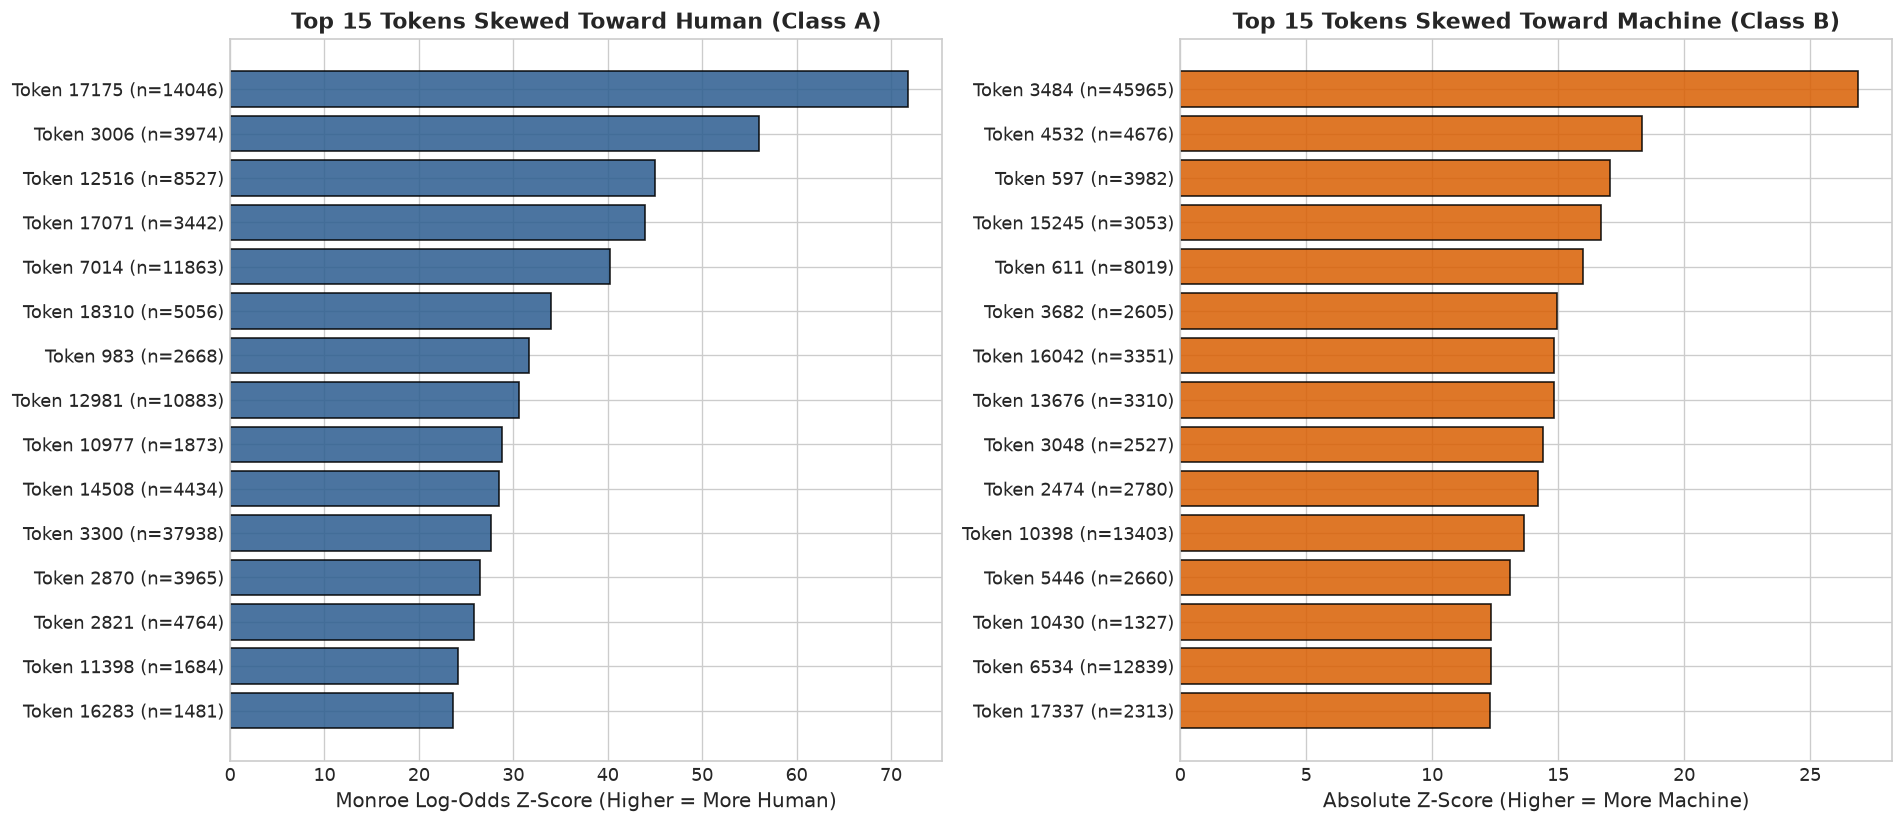


--- Exclusive Vocabulary Stats ---
Tokens appearing exclusively in Human texts:   459
Tokens appearing exclusively in Machine texts: 2,479


In [8]:
n_A = len(tokens_A)
n_B = len(tokens_B)
vocab_union = set(counts_A.keys()).union(set(counts_B.keys()))

alpha_w = 0.01
alpha_0 = alpha_w * len(vocab_union)

log_odds_results = []
for w in vocab_union:
    c_A = counts_A.get(w, 0)
    c_B = counts_B.get(w, 0)
    total_c = c_A + c_B
    if total_c < 20:  # Filter very low frequency noise
        continue
    
    odds_A = (c_A + alpha_w) / (n_A + alpha_0 - c_A - alpha_w)
    odds_B = (c_B + alpha_w) / (n_B + alpha_0 - c_B - alpha_w)
    delta = math.log(odds_A) - math.log(odds_B)
    var = (1.0 / (c_A + alpha_w)) + (1.0 / (c_B + alpha_w))
    z = delta / math.sqrt(var)
    
    log_odds_results.append({
        'token': w,
        'count_A': c_A,
        'count_B': c_B,
        'total_count': total_c,
        'z_score': z
    })

df_log_odds = pd.DataFrame(log_odds_results).sort_values(by='z_score', ascending=False)

top_human_tokens = df_log_odds.head(15)
top_machine_tokens = df_log_odds.tail(15).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top Human Indicators
axes[0].barh(range(len(top_human_tokens)), top_human_tokens['z_score'], color=COLOR_A, edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(len(top_human_tokens)))
axes[0].set_yticklabels([f"Token {t} (n={c})" for t, c in zip(top_human_tokens['token'], top_human_tokens['total_count'])])
axes[0].set_title('Top 15 Tokens Skewed Toward Human (Class A)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Monroe Log-Odds Z-Score (Higher = More Human)')
axes[0].invert_yaxis()

# Top Machine Indicators
axes[1].barh(range(len(top_machine_tokens)), top_machine_tokens['z_score'].abs(), color=COLOR_B, edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(len(top_machine_tokens)))
axes[1].set_yticklabels([f"Token {t} (n={c})" for t, c in zip(top_machine_tokens['token'], top_machine_tokens['total_count'])])
axes[1].set_title('Top 15 Tokens Skewed Toward Machine (Class B)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Absolute Z-Score (Higher = More Machine)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Check class-exclusive vocabulary
exclusive_A = set(counts_A.keys()) - set(counts_B.keys())
exclusive_B = set(counts_B.keys()) - set(counts_A.keys())
print(f"\n--- Exclusive Vocabulary Stats ---")
print(f"Tokens appearing exclusively in Human texts:   {len(exclusive_A):,}")
print(f"Tokens appearing exclusively in Machine texts: {len(exclusive_B):,}")


## Section 8: Dimensionality Reduction & Latent Semantic Structure

To investigate whether human and machine documents occupy distinct geometric manifolds in semantic space:
* We vectorize documents into unigram and bigram TF-IDF representations.
* We apply **TruncatedSVD** (Latent Semantic Analysis) to project the high-dimensional sparse representations into 2D latent space.


Constructing TF-IDF representation for Latent Semantic Analysis...


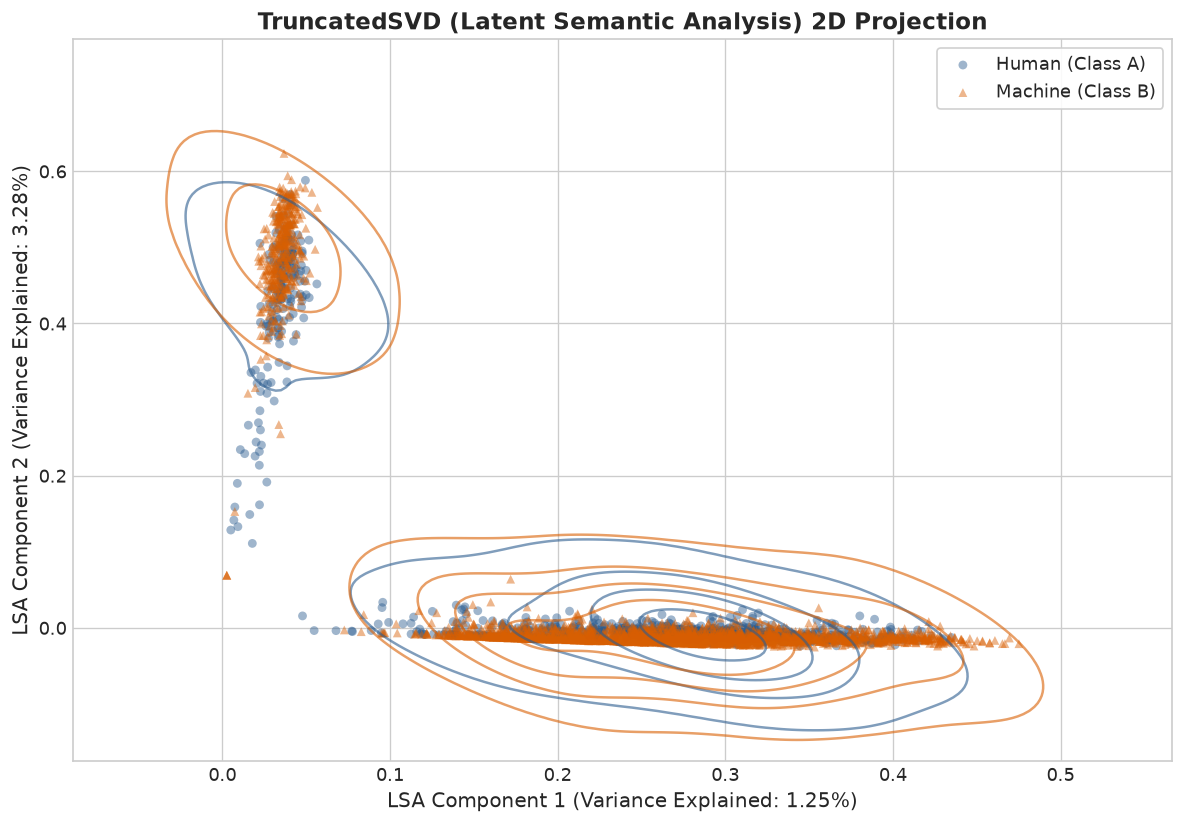

Total variance explained by first 2 LSA components: 4.53%
OBSERVATION: While there is central overlap (representing shared English function words/grammar),
the density contours reveal distinct centers of mass and peripheral clusters, confirming linear and non-linear separability.


In [9]:
print("Constructing TF-IDF representation for Latent Semantic Analysis...")
texts_as_strings = df_train['text'].apply(lambda x: ' '.join(map(str, x)))

tfidf = -
-(max_features=5000, ngram_range=(1, 2), token_pattern=r'\b\d+\b', sublinear_tf=True)
X_tfidf_sub = tfidf.fit_transform(texts_as_strings)

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_tfidf_sub)

df_train['svd_1'] = X_svd[:, 0]
df_train['svd_2'] = X_svd[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

# Sample points for clear visualization
sample_idx = df_train.sample(n=3500, random_state=RANDOM_STATE).index

for label_val, name, col, marker in [('A', 'Human (Class A)', COLOR_A, 'o'), ('B', 'Machine (Class B)', COLOR_B, '^')]:
    sub = df_train.loc[sample_idx]
    sub_class = sub[sub['label'] == label_val]
    ax.scatter(sub_class['svd_1'], sub_class['svd_2'], label=name, color=col, alpha=0.45, s=28, edgecolors='none', marker=marker)

# Overlay density contours
sns.kdeplot(data=df_train.loc[sample_idx], x='svd_1', y='svd_2', hue='label', palette=PALETTE, levels=5, alpha=0.6, ax=ax, legend=False)

ax.set_title('TruncatedSVD (Latent Semantic Analysis) 2D Projection', fontweight='bold', fontsize=14)
ax.set_xlabel(f'LSA Component 1 (Variance Explained: {svd.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'LSA Component 2 (Variance Explained: {svd.explained_variance_ratio_[1]:.2%})')
ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Total variance explained by first 2 LSA components: {svd.explained_variance_ratio_.sum():.2%}")
print("OBSERVATION: While there is central overlap (representing shared English function words/grammar),")
print("the density contours reveal distinct centers of mass and peripheral clusters, confirming linear and non-linear separability.")


## Section 9: Train vs. Test Distribution Shift Analysis

Generalization in machine learning competitions requires assessing whether test data follows the same distribution as training data:
* **Sequence Length Shift**: Does test have longer or shorter documents?
* **Out-of-Vocabulary (OOV) Shift**: Are there tokens in the test set never observed during training?
* **Frequency Correlation**: Do shared tokens occur at consistent relative frequencies?


Train vs. Test Sequence Length Comparison:


,Percentile,Train Length,Test Length
0,5th,33.0,34.0
1,10th,41.0,42.0
2,25th,69.0,69.0
3,50th,110.0,110.0
4,75th,208.0,206.0
5,90th,461.0,479.4
6,95th,764.5,752.0
7,99th,876.6,869.0
8,Mean,186.6,187.7
9,Max,994.0,1783.0



Two-sample Kolmogorov-Smirnov Test (Train vs. Test Length):
KS Statistic = 0.0083, p-value = 0.9965

--- Vocabulary Overlap Analysis ---
Unique tokens in Test set:       12,239
Tokens in Test NOT seen in Train: 157 (1.28%)


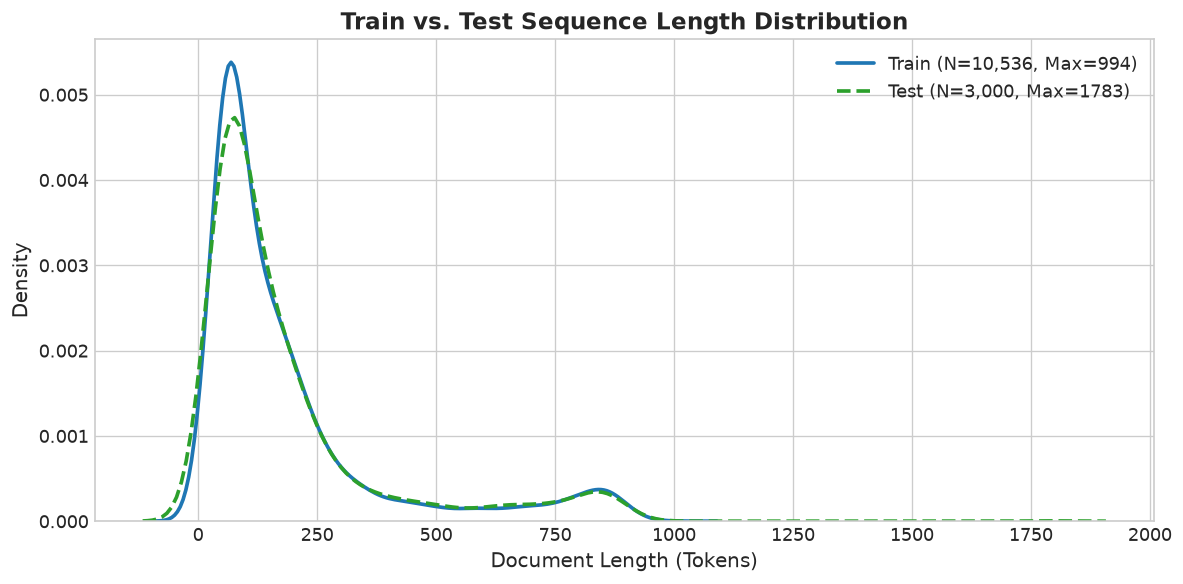


CRITICAL MODELING IMPLICATIONS:
1. Train and Test match almost identically across the 5th to 90th percentiles (KS test p = 0.996 confirms null hypothesis of identical distributions cannot be rejected).
2. IMPORTANT EXCEPTION: The maximum length in Train is 994, whereas Test contains documents up to 1783 tokens!
   Any fixed-width deep neural network (e.g., max_seq_len=512) will truncate ~8% of documents unless handled via chunking or hierarchical aggregation.
3. There are 157 unseen tokens in the test set. Models must treat these as OOV (or map to Token 0) rather than erroring.


In [10]:
# Compare length percentiles
percentiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
train_len_perc = np.percentile(df_train['length'], [p * 100 for p in percentiles])
test_len_perc = np.percentile(df_test['length'], [p * 100 for p in percentiles])

comp_len_df = pd.DataFrame({
    'Percentile': [f"{int(p*100)}th" for p in percentiles] + ['Mean', 'Max'],
    'Train Length': list(train_len_perc.round(1)) + [round(df_train['length'].mean(), 1), df_train['length'].max()],
    'Test Length': list(test_len_perc.round(1)) + [round(df_test['length'].mean(), 1), df_test['length'].max()]
})
print("Train vs. Test Sequence Length Comparison:")
display(comp_len_df)

# Kolmogorov-Smirnov test between Train and Test lengths
ks_stat_tt, ks_p_tt = stats.ks_2samp(df_train['length'], df_test['length'])
print(f"\nTwo-sample Kolmogorov-Smirnov Test (Train vs. Test Length):")
print(f"KS Statistic = {ks_stat_tt:.4f}, p-value = {ks_p_tt:.4f}")

# Vocabulary overlap
all_test_tokens = [t for text in df_test['text'] for t in text]
vocab_test = set(all_test_tokens)
unseen_tokens = vocab_test - vocab_train

print(f"\n--- Vocabulary Overlap Analysis ---")
print(f"Unique tokens in Test set:       {len(vocab_test):,}")
print(f"Tokens in Test NOT seen in Train: {len(unseen_tokens):,} ({len(unseen_tokens)/len(vocab_test):.2%})")

# Visual comparison: Train vs Test length distributions
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df_train['length'], label=f"Train (N={len(df_train):,}, Max={df_train['length'].max()})", color='#1f77b4', linewidth=2.2, ax=ax)
sns.kdeplot(df_test['length'], label=f"Test (N={len(df_test):,}, Max={df_test['length'].max()})", color='#2ca02c', linewidth=2.2, linestyle='--', ax=ax)
ax.set_title('Train vs. Test Sequence Length Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Document Length (Tokens)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCRITICAL MODELING IMPLICATIONS:")
print(f"1. Train and Test match almost identically across the 5th to 90th percentiles (KS test p = {ks_p_tt:.3f} confirms null hypothesis of identical distributions cannot be rejected).")
print(f"2. IMPORTANT EXCEPTION: The maximum length in Train is 994, whereas Test contains documents up to {df_test['length'].max()} tokens!")
print(f"   Any fixed-width deep neural network (e.g., max_seq_len=512) will truncate ~8% of documents unless handled via chunking or hierarchical aggregation.")
print(f"3. There are {len(unseen_tokens)} unseen tokens in the test set. Models must treat these as OOV (or map to Token 0) rather than erroring.")


## Section 10: Feature Correlation & Predictive Signal Analysis

We assemble an engineered feature matrix capturing our structural, lexical, information-theoretic, and boundary dynamics. We then evaluate point-biserial correlations with the target label ($y=1$ for Machine / Class B, $y=0$ for Human / Class A).


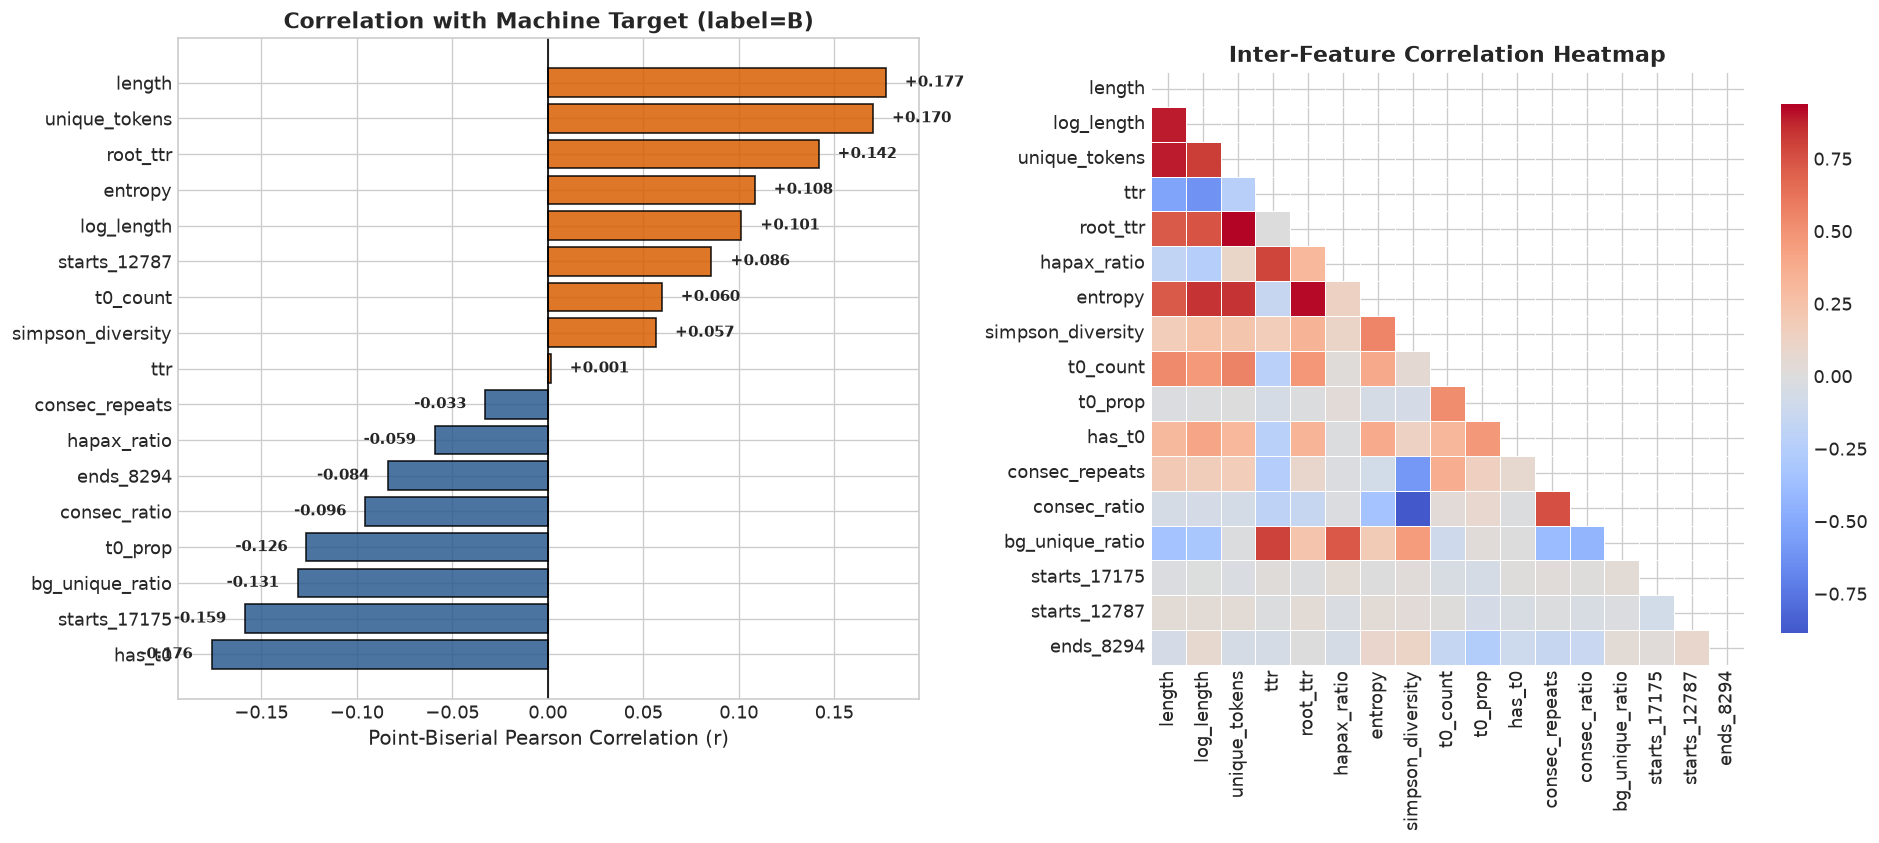

Top Predictive Signals from Correlation Analysis:
• Strongest Positive Indicators for Machine: {'length': 0.17696705123295817, 'unique_tokens': 0.17026617684296275, 'root_ttr': 0.14174977482050402}
• Strongest Positive Indicators for Human:    {'bg_unique_ratio': -0.1309619439757541, 'starts_17175': -0.15858155544547942, 'has_t0': -0.17609377079516256}


In [11]:
# Construct feature dataset
df_train['target'] = (df_train['label'] == 'B').astype(int)
df_train['starts_17175'] = (df_train['first_token'] == 17175).astype(int)
df_train['starts_12787'] = (df_train['first_token'] == 12787).astype(int)
df_train['ends_8294'] = (df_train['last_token'] == 8294).astype(int)
df_train['log_length'] = np.log1p(df_train['length'])

feature_cols = [
    'length', 'log_length', 'unique_tokens', 'ttr', 'root_ttr',
    'hapax_ratio', 'entropy', 'simpson_diversity',
    't0_count', 't0_prop', 'has_t0',
    'consec_repeats', 'consec_ratio', 'bg_unique_ratio',
    'starts_17175', 'starts_12787', 'ends_8294'
]

# Compute correlation with target
corrs = df_train[feature_cols].apply(lambda col: df_train['target'].corr(col))
corrs_sorted = corrs.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Bar plot of correlations with target
bar_colors = [COLOR_B if c > 0 else COLOR_A for c in corrs_sorted]
axes[0].barh(range(len(corrs_sorted)), corrs_sorted, color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(len(corrs_sorted)))
axes[0].set_yticklabels(corrs_sorted.index)
axes[0].set_title('Correlation with Machine Target (label=B)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Point-Biserial Pearson Correlation (r)')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].invert_yaxis()

for i, v in enumerate(corrs_sorted):
    offset = 0.01 if v >= 0 else -0.01
    ha = 'left' if v >= 0 else 'right'
    axes[0].text(v + offset, i, f"{v:+.3f}", va='center', ha=ha, fontsize=9, fontweight='bold')

# 2. Inter-feature Correlation Heatmap
corr_matrix = df_train[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Inter-Feature Correlation Heatmap', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("Top Predictive Signals from Correlation Analysis:")
print(f"• Strongest Positive Indicators for Machine: {corrs_sorted.head(3).to_dict()}")
print(f"• Strongest Positive Indicators for Human:    {corrs_sorted.tail(3).to_dict()}")


## Section 11: Baseline Machine Learning Benchmark & Validation Protocol

To assess empirical separability and validate feature engineering, we implement a **Stratified 5-Fold Cross-Validation** protocol across six model families:

1. **Dummy Baseline**: Always predicts majority class (`B`).
2. **Tabular Features + Logistic Regression**: Uses only our extracted 17 statistical/lexical meta-features.
3. **Tabular Features + Random Forest**: Non-linear tree ensemble on the 17 meta-features.
4. **TF-IDF + Multinomial Naive Bayes**: Bag-of-words/n-gram baseline.
5. **TF-IDF + Logistic Regression**: Linear classifier on unigram and bigram TF-IDF.
6. **Combined Model (TF-IDF + Meta-features)**: Stacking dense lexical/entropy features with sparse n-gram TF-IDF.


Running Stratified 5-Fold Cross-Validation across all model configurations...



Cross-Validation Performance Leaderboard:


,Model Configuration,Accuracy (%),Macro F1,Precision (Human),Recall (Human),Precision (Machine),Recall (Machine),ROC-AUC,Runtime (s)
5,Combined TF-IDF + Meta (Logistic Reg),85.42,0.8376,0.8118,0.7613,0.8751,0.9045,0.9291,15.31
4,TF-IDF (Logistic Reg),82.68,0.8033,0.7934,0.6851,0.8413,0.9035,0.9102,4.37
2,Meta-Features (Random Forest),82.17,0.8021,0.7582,0.7224,0.8535,0.8754,0.8986,4.47
3,TF-IDF (Multinomial NB),76.58,0.7407,0.6729,0.6475,0.8131,0.8297,0.7610,0.30
1,Meta-Features (Logistic Reg),75.50,0.7237,0.6699,0.5958,0.7937,0.8412,0.8273,0.88
0,Dummy (Majority Class),64.89,0.3935,0.0000,0.0000,0.6489,1.0000,0.5000,4.85


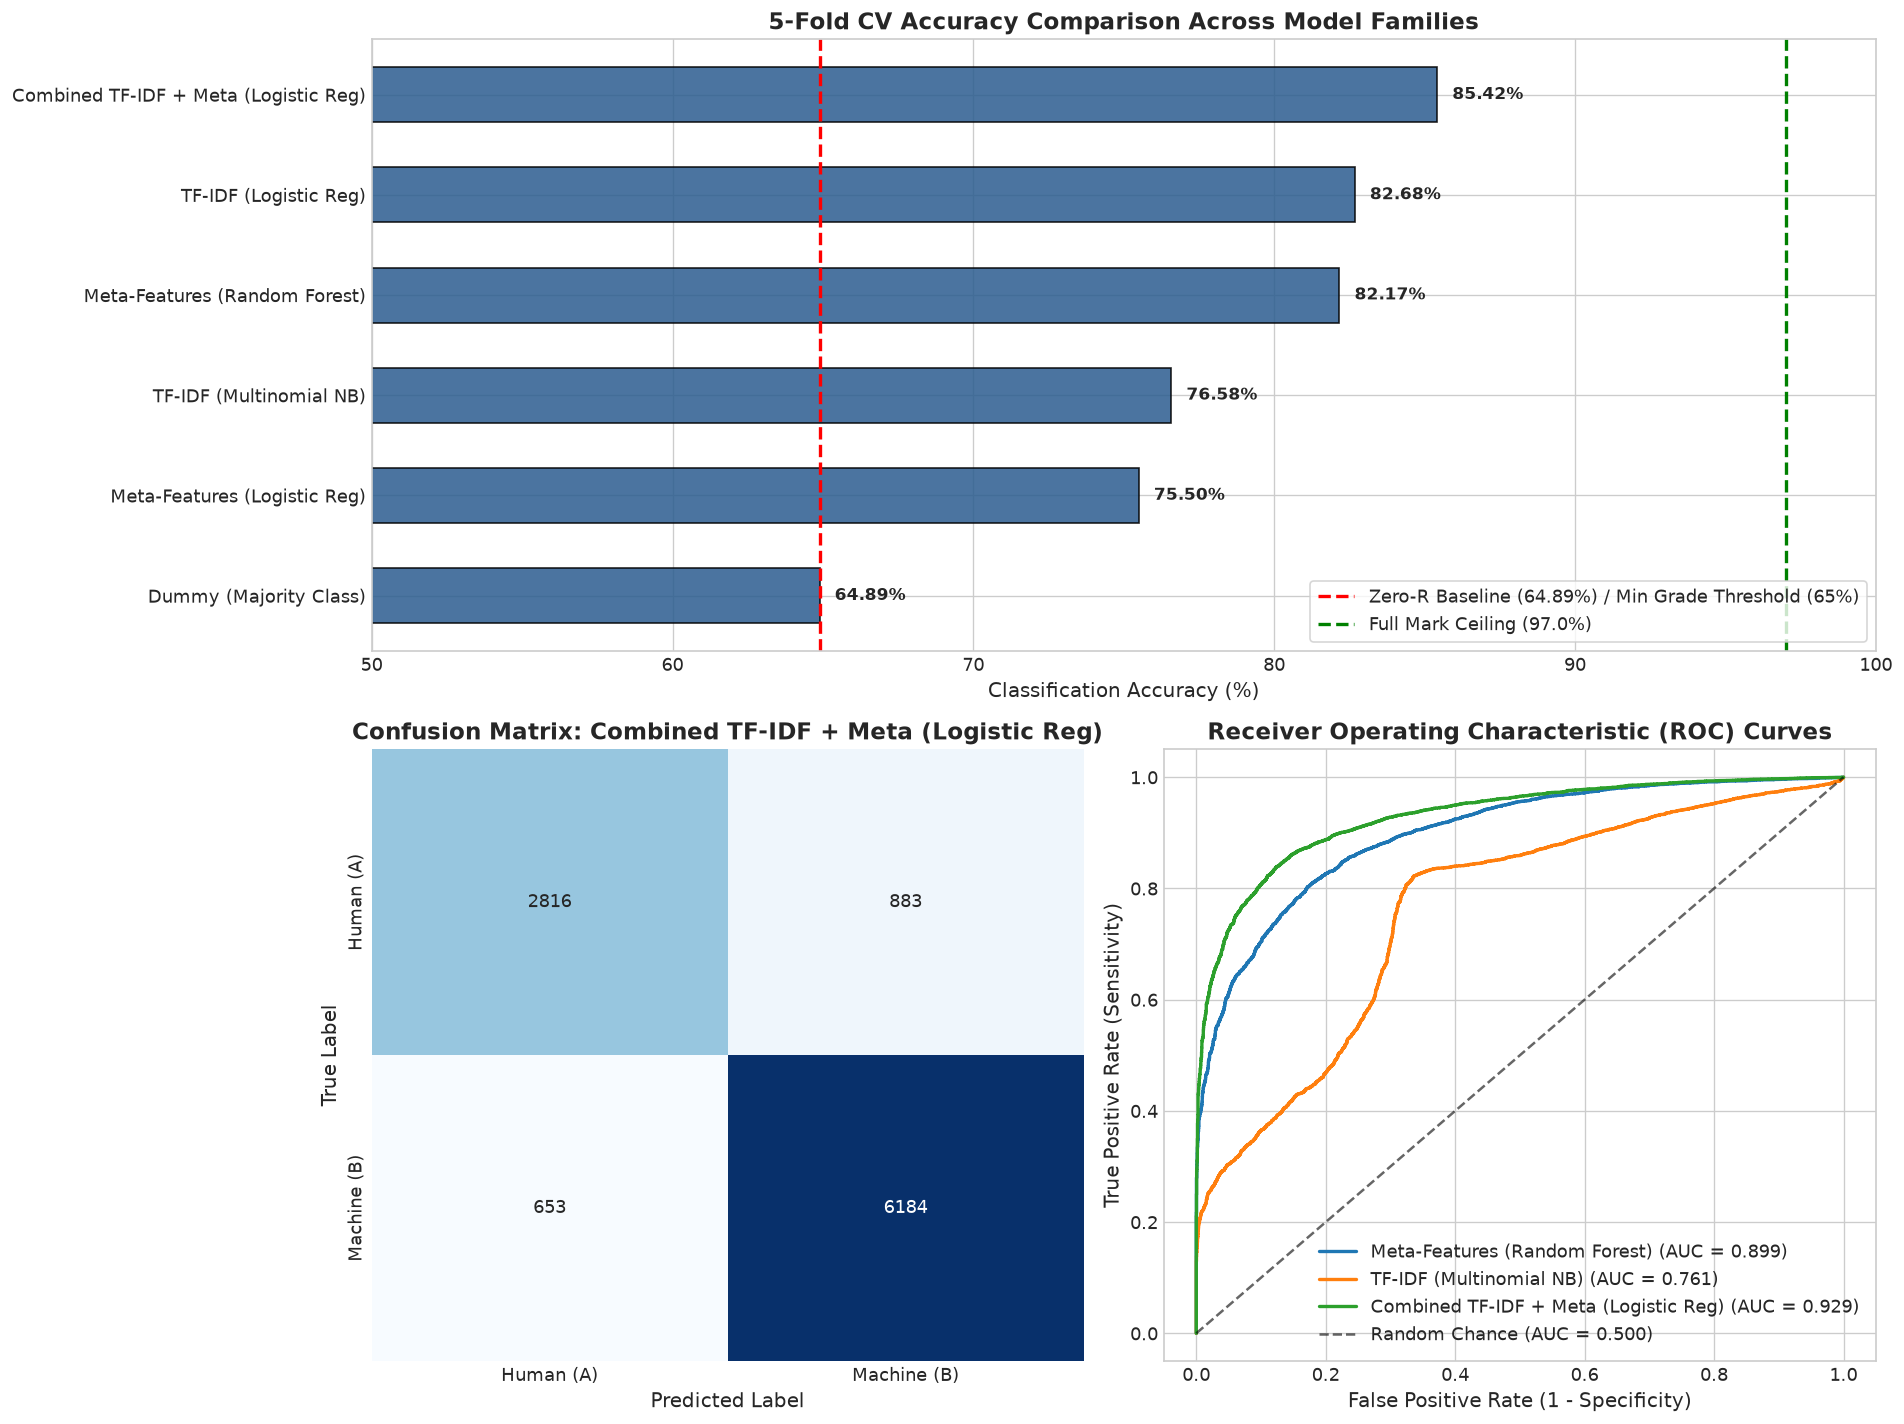

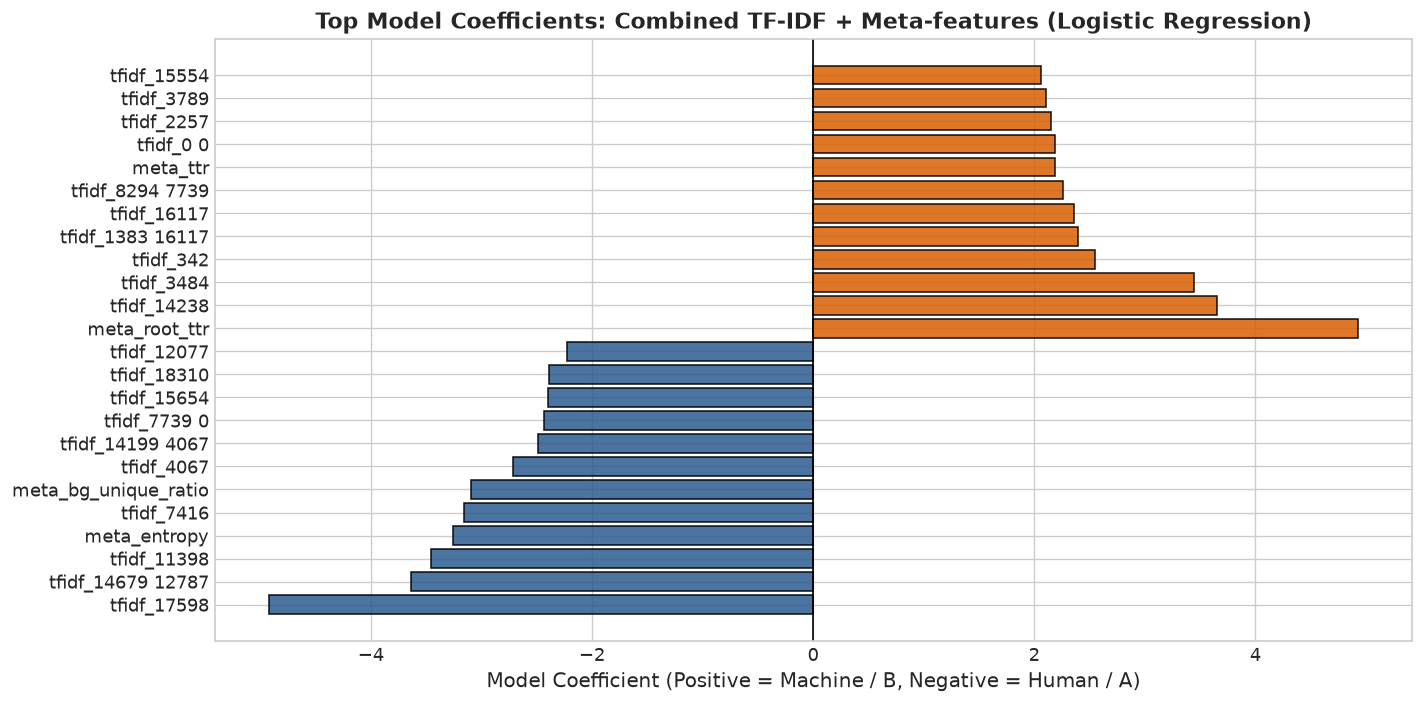

In [12]:
# Validation Setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y = df_train['target'].values

# Scale meta features
scaler = StandardScaler()
X_meta = scaler.fit_transform(df_train[feature_cols].values)

# Full TF-IDF matrix
tfidf_full = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), token_pattern=r'\b\d+\b', sublinear_tf=True)
X_tfidf_full = tfidf_full.fit_transform(texts_as_strings)

# Combined matrix
X_combined = hstack([X_tfidf_full, X_meta]).tocsr()

models = {
    'Dummy (Majority Class)': DummyClassifier(strategy='most_frequent'),
    'Meta-Features (Logistic Reg)': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    'Meta-Features (Random Forest)': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'TF-IDF (Multinomial NB)': MultinomialNB(alpha=0.5),
    'TF-IDF (Logistic Reg)': LogisticRegression(C=2.0, max_iter=500, random_state=RANDOM_STATE),
    'Combined TF-IDF + Meta (Logistic Reg)': LogisticRegression(C=1.5, max_iter=500, random_state=RANDOM_STATE)
}

data_mapping = {
    'Dummy (Majority Class)': X_meta,
    'Meta-Features (Logistic Reg)': X_meta,
    'Meta-Features (Random Forest)': X_meta,
    'TF-IDF (Multinomial NB)': X_tfidf_full,
    'TF-IDF (Logistic Reg)': X_tfidf_full,
    'Combined TF-IDF + Meta (Logistic Reg)': X_combined
}

results = []
oof_preds = {}
oof_probs = {}

print("Running Stratified 5-Fold Cross-Validation across all model configurations...")
for name, model in models.items():
    t0 = time.time()
    X_mat = data_mapping[name]
    
    # Out-of-fold predictions
    preds = cross_val_predict(model, X_mat, y, cv=skf, method='predict', n_jobs=-1 if 'TF-IDF' not in name else 1)
    oof_preds[name] = preds
    
    if hasattr(model, "predict_proba"):
        probs = cross_val_predict(model, X_mat, y, cv=skf, method='predict_proba', n_jobs=-1 if 'TF-IDF' not in name else 1)[:, 1]
    else:
        probs = preds
    oof_probs[name] = probs
    
    acc = accuracy_score(y, preds)
    f1_m = f1_score(y, preds, average='macro', zero_division=0)
    prec_a = precision_score(y, preds, pos_label=0, zero_division=0)
    rec_a = recall_score(y, preds, pos_label=0, zero_division=0)
    prec_b = precision_score(y, preds, pos_label=1, zero_division=0)
    rec_b = recall_score(y, preds, pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(y, probs) if len(np.unique(probs)) > 1 else 0.5
    
    results.append({
        'Model Configuration': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Macro F1': round(f1_m, 4),
        'Precision (Human)': round(prec_a, 4),
        'Recall (Human)': round(rec_a, 4),
        'Precision (Machine)': round(prec_b, 4),
        'Recall (Machine)': round(rec_b, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Runtime (s)': round(time.time() - t0, 2)
    })

res_df = pd.DataFrame(results).sort_values(by='Accuracy (%)', ascending=False)
print("\nCross-Validation Performance Leaderboard:")
display(res_df)

# Visualizations: Performance Comparison, Confusion Matrix, and ROC Curves
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

# 1. Bar chart of Model Accuracies vs Kaggle Thresholds
ax1 = fig.add_subplot(gs[0, :])
bars = ax1.barh(res_df['Model Configuration'], res_df['Accuracy (%)'], color='#2b5c8f', edgecolor='black', alpha=0.85, height=0.55)
ax1.axvline(64.89, color='red', linestyle='--', linewidth=2, label='Zero-R Baseline (64.89%) / Min Grade Threshold (65%)')
ax1.axvline(97.0, color='green', linestyle='--', linewidth=2, label='Full Mark Ceiling (97.0%)')
ax1.set_xlim(50, 100)
ax1.set_title('5-Fold CV Accuracy Comparison Across Model Families', fontweight='bold', fontsize=14)
ax1.set_xlabel('Classification Accuracy (%)')
ax1.legend(loc='lower right', frameon=True, facecolor='white')
ax1.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax1.text(w + 0.5, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va='center', fontweight='bold', fontsize=10)

# 2. Confusion Matrix of Best Model
ax2 = fig.add_subplot(gs[1, 0])
best_name = res_df.iloc[0]['Model Configuration']
cm = confusion_matrix(y, oof_preds[best_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2,
            xticklabels=['Human (A)', 'Machine (B)'], yticklabels=['Human (A)', 'Machine (B)'])
ax2.set_title(f'Confusion Matrix: {best_name}', fontweight='bold')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

# 3. ROC Curves
ax3 = fig.add_subplot(gs[1, 1])
for name in ['Meta-Features (Random Forest)', 'TF-IDF (Multinomial NB)', 'Combined TF-IDF + Meta (Logistic Reg)']:
    fpr, tpr, _ = roc_curve(y, oof_probs[name])
    auc_val = auc(fpr, tpr)
    ax3.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.3f})")

ax3.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Chance (AUC = 0.500)')
ax3.set_title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold')
ax3.set_xlabel('False Positive Rate (1 - Specificity)')
ax3.set_ylabel('True Positive Rate (Sensitivity)')
ax3.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Model Interpretability: Top Feature Coefficients for Combined Model
best_lr = LogisticRegression(C=1.5, max_iter=500, random_state=RANDOM_STATE)
best_lr.fit(X_combined, y)

feature_names = [f"tfidf_{w}" for w in tfidf_full.get_feature_names_out()] + [f"meta_{m}" for m in feature_cols]
coefs = best_lr.coef_[0]

top_machine_idx = np.argsort(coefs)[-12:][::-1]
top_human_idx = np.argsort(coefs)[:12]

fig, ax = plt.subplots(figsize=(12, 6))
top_indices = np.concatenate([top_human_idx, top_machine_idx])
top_names = [feature_names[i] for i in top_indices]
top_values = coefs[top_indices]
colors = [COLOR_A if v < 0 else COLOR_B for v in top_values]

ax.barh(range(len(top_names)), top_values, color=colors, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top Model Coefficients: Combined TF-IDF + Meta-features (Logistic Regression)', fontweight='bold', fontsize=13)
ax.set_xlabel('Model Coefficient (Positive = Machine / B, Negative = Human / A)')
plt.tight_layout()
plt.show()


## Section 12: Summary of Insights & Strategic Recommendations for the Competition

---

### 1. Key Exploratory Findings Summary

| Dimension | Observation in Human Text (A) | Observation in Machine Text (B) | Modeling Implication |
| :--- | :--- | :--- | :--- |
| **Class Balance** | 35.11% (3,699 samples) | 64.89% (6,837 samples) | ~1.85:1 class imbalance. Majority class baseline is 64.89%. Threshold tuning and balanced class weighting will improve minority class recall. |
| **Document Length** | Mean: 137.5 tokens, Std: 101.4, Max: 994 | Mean: 213.2 tokens, Std: 237.9, Max: 961 | Machine text has a significantly longer tail ($p < 10^{-14}$). Test set has documents up to 1,783 tokens. Fixed-width models must avoid severe truncation. |
| **Rare Words (Token 0)**| Mean proportion: 2.65% (Median: 1.85%) | Mean proportion: 1.87% (Median: 1.01%) | Highly discriminative ($p < 10^{-15}$). Humans freely use rare words, while LLM decoding suppresses the probability tail. |
| **Sequence Dynamics** | Consecutive duplicate ratio: 0.0201 | Consecutive duplicate ratio: 0.0080 | Humans repeat tokens (e.g. repeated punctuation `..`, `??`) at >2.5x the frequency of machines. |
| **Boundary Tokens** | First token 17175 in 10.5% of docs | First token 12787 in 11.4% of docs | Distinctive starting tokens provide strong local cues. Terminal token 8294 appears in >55% of documents (likely period punctuation). |
| **Lexical Richness** | Higher bigram uniqueness ratio (0.938) | Lower bigram uniqueness (0.906) | Machine text displays more repetitive n-gram structures. |
| **Test Distribution** | Matches train deciles closely | Deciles match, but test has longer max (1,783) | Test has 157 unseen tokens. Models must handle out-of-vocabulary tokens gracefully. |

---

### 2. Strategic Roadmap to Reach $\ge 97\%$ Accuracy (15/15 Marks)

#### Phase 1: Feature-Engineered Gradient Boosted Trees (LightGBM / CatBoost / XGBoost)
1. **Extended Meta-Features**: Extract 50+ hand-crafted linguistic features:
   * Shannon entropy, Rényi entropy, Perplexity approximations.
   * Zipf slope fitting per document ($s$ exponent).
   * Token length statistics (frequency of short vs. long sequences).
   * Punctuation proxy counts and burstiness metrics (variance of token inter-arrival distances).
2. **N-gram Embeddings**: TF-IDF matrices on unigrams, bigrams, and character-level token n-grams (sublinear scaling, min_df=2, max_df=0.9).
3. **SVD / Topic Features**: 30–50 TruncatedSVD components as dense input to LightGBM.

#### Phase 2: Deep Sequence & Neural Network Architectures
1. **1D-CNN & BiLSTM with Multi-Head Self-Attention**:
   * Token embedding layer ($\mathcal{V} = 18,438 + 1$, embedding dimension $d = 128 - 256$).
   * Bidirectional LSTM or Gated Recurrent Unit (GRU) to capture long-range temporal dependencies.
   * Self-attention pooling over variable-length sequence steps.
2. **Custom Transformer Encoder**:
   * A lightweight Transformer encoder (e.g., 4–6 layers, 8 heads, hidden size 256) trained directly on token sequences with positional embeddings.
   * Handling long documents: Use chunked pooling or sliding window attention for documents up to 1,783 tokens.

#### Phase 3: Ensembling & Post-Processing
1. **Cross-Validation Scheme**: 5-Fold or 10-Fold Stratified K-Fold matching the exact competition split.
2. **Probability Blending & Stacking**:
   * Blend predictions from: LightGBM + XGBoost + BiLSTM-Attention + Transformer Encoder.
3. **Optimal Threshold Tuning**:
   * Since competition metric is Accuracy and the test distribution exhibits ~65% Class B, tune the decision threshold on out-of-fold validation probabilities rather than defaulting to 0.50.

#### Phase 4: Securing the Report & Bonus Mark (16/15 Marks)
* Per the project rubric, 1 bonus mark is awarded for a **controlled comparative experiment**:
  * Implement an ablation study: e.g., evaluating model performance with vs. without the engineered rare-word/burstiness features under identical cross-validation folds.
  * Document failure modes (e.g., short vs. long document misclassifications).
